# Final project for HDEq Skills: 
`Due: Wednesday 3rd December 2025 @ 12:00 (noon)`

## Instruction and marking scheme

Your submission (like your assignments) will be a Jupyter Notebook (.ipynb file).  For your analysis and discussion use Markdown cells instead of comments in the code.

For the presentation and coding style:
- The plots should be in a good size, properly labelled and markers/lines wisely chosen. It might be a good idea to combine some plots and put several curves together for easier comparison and conciseness. 
- Your code should be well commented with meaningful variable names and good structures. You don't need to over comment it though!
- The writing should be clear and concise with minimal language or typing mistakes.


It is important that you think about good academic practice when you construct your answers. The work you submit must reflect **your own understanding**, in line with the School's policy on academic misconduct: https://teaching.maths.ed.ac.uk/undergraduate/studies/assessment/academic-misconduct and no generative AI is permitted. Any form of plagiarism or AI use that is detected by the software or markers will be reported to the school for the due process.

## Part 1: Wave equation with linear damping

Consider the following wave equation that includes a damping term


\begin{equation}
u_{tt} + \nu u_{t} = c^2 u_{xx}
\end{equation}

with the boundary conditions
\begin{equation}
u\left(x = 0, t\right) = 0 , \quad u\left(x = L, t\right) = 0,
\end{equation}
and the initial conditions
\begin{equation*}
u\left(x, t=0\right) = f(x) = \exp\left(\sin^2\left(\frac{2\pi x}{L}\right)\right)-1 , \quad u_t\left(x, t=0\right) = 0,
\end{equation*}

For this problem, let's set $L=20$, $\nu = 0.2$ and $c = 1$.

We use a method to solve this PDE that is known as "Galerkin". In so doing, we approximate the solution with

\begin{equation*}
u(x, t) \approx \sum_{n=1}^{N} f_n(t) \sin(\lambda_n x) 
\end{equation*}

and then derive an appropriate ODE for $f_n(t)$ to solve numerically. This is a form of separation of variables in which the equations for the functions of time are solved numerically rather than by hand. It can be shown that when $N \to \infty$ the above series converges to the exact solution. 

🚩 **Task 1.1 (1 mark)** Considering the above form of solution, find $\lambda_n$ in terms of $n$ and $L$. 

🚩 **Task 1.2 (1 mark)** Using the assumed form of solution and PDE, find an ODE that describes the evolution of $f_n(t)$ in time, (where $n = 1, 2, \dots, N $).

🚩 **Task 1.3 (2 marks)** Using the initial conditions of the PDE and your knowledge of Fourier series, find two initial conditions for $f_n$ and $\cfrac{df_n}{dt}$ at $t=0$. Your answer in this part might in the form of an integral, which you should not evaluate at this point (we will calculate this integral later numerically).


**Answer:**

**Task 1.1**

Because we write the solution as
$u(x,t) \approx \sum_{n=1}^{N} f_n(t),\sin(\lambda_n x)$
and we must satisfy the boundary conditions $u(0,t)=0$ and $u(L,t)=0$, we need
$\sin(\lambda_n \cdot 0)=0$ (always true) and $\sin(\lambda_n L)=0$.
The second condition requires $\lambda_n L = n\pi$ for some integer $n$.
So the allowed values are
$\lambda_n = \dfrac{n\pi}{L}$ for $n = 1,2,3,\dots$.

**Task 1.2**

We start from the assumed form of the solution

$u(x,t) = \sum_{n=1}^{N} f_n(t),\sin(\lambda_n x)$,

where $\lambda_n = n\pi/L$.

Compute the derivatives that appear in the PDE:

First time derivative:

$u_t(x,t) = \sum_{n=1}^{N} f_n'(t),\sin(\lambda_n x)$

Second time derivative:

$u_{tt}(x,t) = \sum_{n=1}^{N} f_n''(t),\sin(\lambda_n x)$

Second space derivative:

$u_{xx}(x,t) = \sum_{n=1}^{N} f_n(t),\dfrac{d^2}{dx^2}\sin(\lambda_n x)
= \sum_{n=1}^{N} f_n(t),(-\lambda_n^2)\sin(\lambda_n x)$

Now insert these into the PDE

$u_{tt} + \nu u_t = c^2 u_{xx}$, you get:
$\sum_{n=1}^{N} f_n''(t)\sin(\lambda_n x) + \nu \sum_{n=1}^{N} f_n'(t)\sin(\lambda_n x)
= c^2 \sum_{n=1}^{N} (-\lambda_n^2) f_n(t)\sin(\lambda_n x)$


Collecting terms, we get

$\sum_{n=1}^{N} \left[f_n''(t) + \nu f_n'(t) + c^2 \lambda_n^2 f_n(t)\right]\sin(\lambda_n x) = 0$.

Because the functions $\sin(\lambda_n x)$ are orthogonal and independent, each bracket must be zero. Therefore, for 
each mode $n$ we obtain the ODE
$f_n''(t) + \nu f_n'(t) + c^2 \lambda_n^2 f_n(t) = 0,\quad n=1,2,\dots,N.$

**Task 1.3**

We use the expansion

$u(x,t) = \sum_{n=1}^{N} f_n(t),\sin(\lambda_n x)$.

At $t=0$ this gives

$u(x,0) = \sum_{n=1}^{N} f_n(0),\sin(\lambda_n x)$.

But from the PDE we also know that

$u(x,0) = f(x) = \exp(\sin^2(2\pi x/L)) - 1$.

So $f(x)$ has the sine–series coefficients $f_n(0)$, and by the usual Fourier sine formula on $(0,L)$ we get

$f_n(0) = \dfrac{2}{L}\int_0^L \left[\exp(\sin^2(2\pi x/L)) - 1\right]\sin(\lambda_n x),dx.$

For the time derivative, from the series we have

$u_t(x,t) = \sum_{n=1}^{N} f_n'(t),\sin(\lambda_n x)$,

so at $t=0$

$u_t(x,0) = \sum_{n=1}^{N} f_n'(0),\sin(\lambda_n x)$.

The initial condition says $u_t(x,0)=0$ for all $x$, and by orthogonality of the sine functions this implies

$f_n'(0) = 0$ for every $n$.

So the two initial conditions for each mode are:

$f_n(0) = \dfrac{2}{L}\int_0^L \left[\exp(\sin^2(2\pi x/L)) - 1\right]\sin(\lambda_n x),dx$

$f_n'(0) = 0$.

🚩 **Task 1.4 (3 marks)** Write a function that takes $n$ (the index of the terms in the series solution, for example $n=3$ corresponds to $f_3(0)$) as an input and returns $f_n(0)$. You might solve this part using different tools: 1) `sympy` module or 2) direct numerical calculation using  `scipy.integrate` (see the documentation [here](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html)). Make sure your final result is a numerical real value (not symbolic expressions). Remember from your labs that you can use `.N()` method to evaluate a sympy expression (if you decide to use `sympy`, which is not the only way to complete this task).

Once you have written your function, use it to calculate $f_n(0)$ for $L=20$, $n=7$ and the given initial condition $u(x, t=0) = \exp\left(\sin^2\left(\frac{2\pi x}{L}\right)\right)-1$.

In [28]:
import sympy as sym
import numpy as np

L = 20   # given constant

def calc_fn_0(n):
    x = sym.symbols('x', real=True)

    # build the expression for the initial condition and the sine mode
    f_init = sym.exp(sym.sin(2*sym.pi*x/L)**2) - 1
    basis   = sym.sin(n * sym.pi * x / L)

    # inner product integral for the Fourier coefficient
    I = sym.integrate(f_init * basis, (x, 0, L))

    # apply the normalization factor 2/L
    fn0 = (2/L) * I

    # return a real numerical value
    return sym.N(fn0)

# example: compute f_7(0)
value = calc_fn_0(7)
print("f_7(0) =", value)


f_7(0) = -0.154357198879035


🚩 **Task 1.5 (4 marks)** Write a function to solve the ODEs that you derived in 'Task 1.2' for each $f_n(t)$. Your function takes $n$ (the index of terms in the solution series) and `t_vec` (the vector of times at which you want to have the solution). Then, it calculates the corresponding initial conditions ($f_n$ and $\cfrac{df}{dt}$ at $t=0$), solves the associated ODE and returns the solution at each point in `t_vec`. Use `odeint` to solve the ODE numerically. You may also use the function you wrote in the previous task.

Use the function to plot $f_1(t)$, $f_2(t)$ and $f_3(t)$ for `t_vec = np.linspace(0, 100, 1001)`.

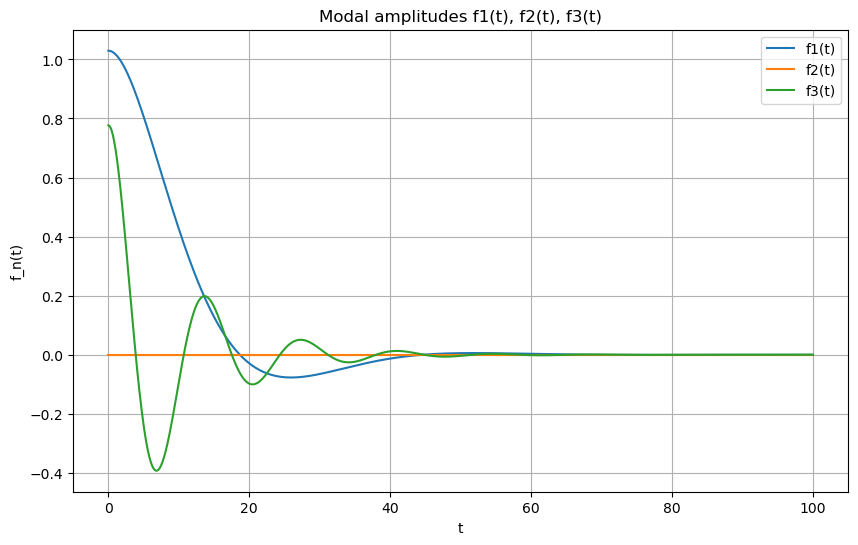

In [29]:
import matplotlib.pyplot as plt
from scipy.integrate import odeint
# and this is the line in case the figure does not show up!
%matplotlib inline

nu = 0.2
c = 1
L = 20

def dF_dt(F, t, k):
    '''
    this function defines the RHS of the system of ODEs for f_n's
    ----------------------------------------------------
    '''
    f_val  = F[0]      # f_n(t)
    f_der  = F[1]      # f_n'(t)

    # eigenvalue term
    lam_n = k * np.pi / L

    # ODE: f'' = -nu f' - c^2 λ_n^2 f
    f_second = -nu * f_der - (c**2) * (lam_n**2) * f_val

    return [f_der, f_second]


def fn_solve(k, t_vec):
    '''
    This function derives the solution of f_k(t) for all the times in 't_vec'
    'k' is given as an input and marks the index of the term in series solution 
    '''

    # symbolic variable for integration
    xi = sym.symbols("xi", real=True)

    # initial condition: compute Fourier coefficient at t=0
    init_expr = sym.exp(sym.sin(2*sym.pi*xi/L)**2) - 1
    basis_fn  = sym.sin(k * sym.pi * xi / L)

    coeff_integral = sym.integrate(init_expr * basis_fn, (xi, 0, L))

    # numerical coefficient
    f_start = float((2/L) * coeff_integral)

    # time derivative at zero
    df_start = 0.0

    init_vec = [f_start, df_start]

    # solve ODE numerically
    sol = odeint(dF_dt, init_vec, t_vec, args=(k,))

    return sol[:, 0]


# time vector
t_vec = np.linspace(0, 100, 1001)

# compute first few modal functions
f1 = fn_solve(1, t_vec)
f2 = fn_solve(2, t_vec)
f3 = fn_solve(3, t_vec)

# plot
plt.figure(figsize=(10,6))
plt.plot(t_vec, f1, label='f1(t)')
plt.plot(t_vec, f2, label='f2(t)')
plt.plot(t_vec, f3, label='f3(t)')
plt.xlabel("t")
plt.ylabel("f_n(t)")
plt.title("Modal amplitudes f1(t), f2(t), f3(t)")
plt.grid(True)
plt.legend()
plt.show()


🚩 **Task 1.6 (4 marks)** Write a function that takes $N$ (the total number of terms in the sine series of the solution), `t_vec` and `x_vec` (which is the vector of points in space) as inputs and returns the solution $u(x,t)$ of the PDE at the times `t_vec` and points `x_vec`. Your function output should be a $N_T \times N_X$ numpy array, where $N_T$ is the number of points in time (i.e. the size of `t_vec`) and  $N_X$ is the number of points in space (i.e. the size of `x_vec`). Make good use of the functions you already wrote in the previous tasks.

With this function, find the solution for 

`x_vec = np.linspace(0, L, 201)`

`t_vec = np.linspace(0, 100, 1001)` 

`N =7`

Make an animation to show how $u(x,t)$ changes in time (each frame of animation is the solution at all spatial points but for one specific point in time)

In [30]:
def waveeq_dam_solve(N, t_vec, x_vec):
    '''
    Computes the approximate solution u(x,t) to the damped wave equation
    using a truncated sine series with N terms. The result is evaluated
    for every time in t_vec and every spatial point in x_vec.

    Returns:
        u_x_t : 2D array with shape (len(t_vec), len(x_vec)),
                where each row corresponds to a time and each column
                to a position in space.
    '''

    # how many points we have in time and space
    N_T = len(t_vec)
    N_X = len(x_vec)

    # this will store the full u(x,t) surface
    u_x_t = np.zeros((N_T, N_X))

    # build up the solution by adding each sine mode
    for k in range(1, N+1):

        # get the time-dependent part for this mode
        f_k_t = fn_solve(k, t_vec)     # length N_T

        # spatial shape of this mode: sin(kπx/L)
        sin_profile = np.sin(k * np.pi * x_vec / L)   # length N_X

        # combine time and space parts (outer product)
        # f_k(t) varies down the rows, sin_profile across the columns
        u_x_t += f_k_t[:, None] * sin_profile[None, :]

    return u_x_t


# example usage
x_vec = np.linspace(0, L, 201)
t_vec = np.linspace(0, 100, 1001)
N = 7

# solution
u_x_t = waveeq_dam_solve(N, t_vec, x_vec)
print(u_x_t)


[[0.00000000e+00 2.36365858e-03 5.05293657e-03 ... 5.05293657e-03
  2.36365858e-03 1.80038602e-17]
 [0.00000000e+00 2.52538816e-03 5.37462689e-03 ... 5.37462689e-03
  2.52538816e-03 1.92670628e-17]
 [0.00000000e+00 3.00455042e-03 6.32771002e-03 ... 6.32771002e-03
  3.00455042e-03 2.30096014e-17]
 ...
 [0.00000000e+00 1.56298247e-06 3.11390350e-06 ... 3.11390350e-06
  1.56298247e-06 1.22012516e-20]
 [0.00000000e+00 1.62847418e-06 3.24394269e-06 ... 3.24394269e-06
  1.62847418e-06 1.27130770e-20]
 [0.00000000e+00 1.67979346e-06 3.34578215e-06 ... 3.34578215e-06
  1.67979346e-06 1.31142202e-20]]


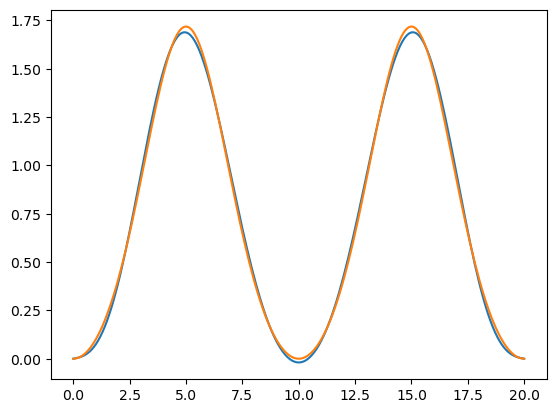

In [31]:
# Assuming the PDE's solution is stored in u_x_t[:,:],
# compare the approx. solution at t=0 with the initial condition
plt.plot(x_vec, u_x_t[0,:])
plt.plot(x_vec,np.exp((np.sin(2*np.pi*x_vec/L))**2)-1)

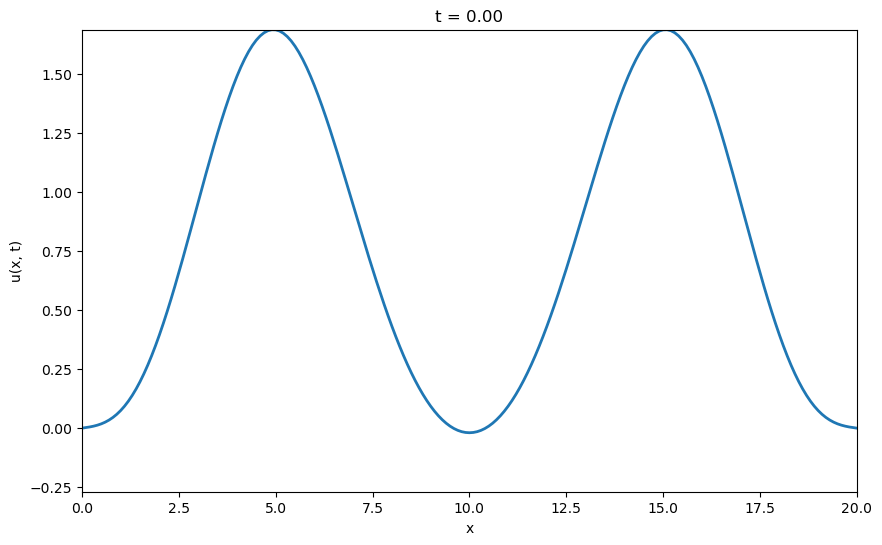

In [32]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

# set up the figure where the spatial slice will be drawn
fig, ax = plt.subplots(figsize=(10, 6))

# an empty line that will be filled in by the animation
line, = ax.plot([], [], lw=2)

# x-range is always the domain [0, L]
ax.set_xlim(0, L)

# y-range taken from the full solution so nothing gets clipped
ax.set_ylim(u_x_t.min(), u_x_t.max())

ax.set_xlabel("x")
ax.set_ylabel("u(x, t)")
ax.set_title("damped wave – time snapshot")

def update(frame):
    """Put the spatial profile u(x,t) for the given timestep on the plot."""
    line.set_data(x_vec, u_x_t[frame])
    # update the title so it reflects the current time value
    ax.set_title(f"t = {t_vec[frame]:.2f}")
    return line,

# run the animation: each frame shows profile at a new time
anim = FuncAnimation(fig, update, frames=len(t_vec), interval=15)

# display the result directly in the notebook
HTML(anim.to_html5_video())


🚩 **Task 1.7 (2 marks)** Examine how the solution changes for different values of $N$. Consider $N=3$, $N=7$ and $N=11$. Show the animation of the solution for all the three cases in one plot and compare them with each other. Discuss and analyse your results (for example, are three terms enough to get an acceptable solution? What about seven?)

In [33]:
from IPython.display import HTML
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# The N-values we want to compare side–by–side
N_values = [3, 7, 11]

# Precompute the three solutions so the animation runs smoothly
solutions = {N: waveeq_dam_solve(N, t_vec, x_vec) for N in N_values}

# Set up the figure where all curves will be drawn
fig, ax = plt.subplots(figsize=(10, 6))

# create one line object for each N (so they all appear together)
lines = []
colours = ['red', 'green', 'blue']
for colour, N in zip(colours, N_values):
    ln, = ax.plot([], [], lw=2, color=colour, label=f"N = {N}")
    lines.append(ln)

# the exact initial displacement (the “true” shape)
initial_shape = np.exp(np.sin(2 * np.pi * x_vec / L)**2) - 1
ax.plot(x_vec, initial_shape, 'k--', lw=2, label="Initial profile")

# also show the N=3 approximation at t=0 (just to compare how rough it is)
init_N3 = solutions[3][0]
ax.plot(x_vec, init_N3, '--', color='cyan', lw=2, label="N = 3 approximation at t=0")

# choose nice axis limits using all computed data
all_min = min(np.min(solutions[N]) for N in N_values)
all_max = max(np.max(solutions[N]) for N in N_values)

ax.set_xlim(0, L)
ax.set_ylim(all_min, all_max)

ax.set_xlabel("x")
ax.set_ylabel("u(x, t)")
ax.legend()

# function that updates the picture every frame
def update(frame):
    # update each coloured line with its current time-slice
    for ln, N in zip(lines, N_values):
        ln.set_data(x_vec, solutions[N][frame])

    # update the displayed time
    ax.set_title(f"t = {t_vec[frame]:.2f}")
    return lines

# build the animation
anim = FuncAnimation(fig, update, frames=len(t_vec), interval=20)

# hide static figure and show the animation instead
plt.close()
HTML(anim.to_html5_video())


For $N=3$, the approximation is quite rough. It captures the general behaviour but loses many details of the initial profile. When $N=7$, the solution improves a lot: the shape is much closer to the true displacement, and the motion looks more realistic. With $N=11$, the result is smoother and more accurate, although the improvement over $N=7$ is smaller.Thus, $N=3$ is too low, $N=7$ gives a good approximation, and $N=11$ is better but with diminishing returns.

🚩 **Task 1.8 (1 marks)** Change the damping parameter to $\nu = 2$, and repeat the 'task 1.6' (for $N=7$ and keep all other parameters the same). In few sentences, explain the changes caused by increasing the damping.

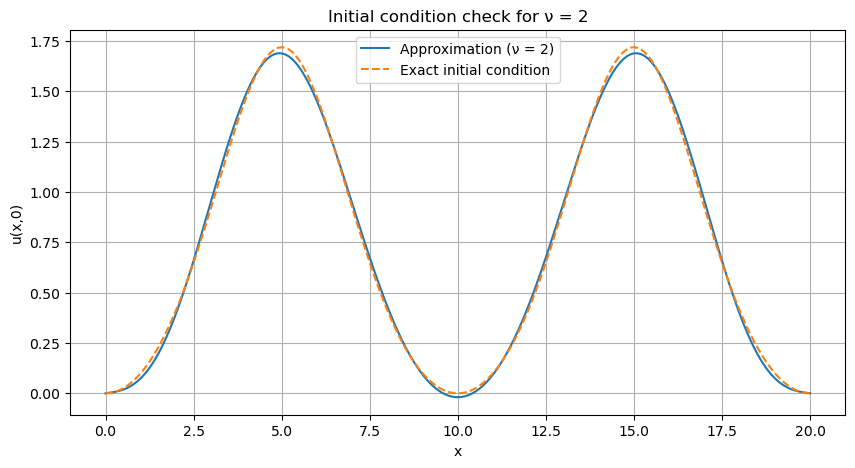

In [34]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# stronger damping
nu = 2
N = 7

# space and time grids
x_vec = np.linspace(0, L, 201)      # 201 points from 0 to L
t_vec = np.linspace(0, 100, 1001)   # 1001 time points from 0 to 100

# solution u(x,t) with ν = 2
u_x_t = waveeq_dam_solve(N, t_vec, x_vec)

# check initial condition at t = 0
plt.figure(figsize=(10, 5))
plt.plot(x_vec, u_x_t[0, :], label="Approximation (ν = 2)")
plt.plot(x_vec,
         np.exp(np.sin(2*np.pi*x_vec/L)**2) - 1,
         '--', label="Exact initial condition")
plt.xlabel("x")
plt.ylabel("u(x,0)")
plt.title("Initial condition check for ν = 2")
plt.legend()
plt.grid(True)
plt.show()

# animation of u(x,t) for ν = 2
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot([], [], lw=2)

ax.set_xlim(0, L)
ax.set_ylim(np.min(u_x_t), np.max(u_x_t))
ax.set_xlabel("x")
ax.set_ylabel("u(x,t)")
ax.set_title("Damped wave equation (ν = 2, N = 7)")

def update(frame):
    line.set_data(x_vec, u_x_t[frame, :])
    ax.set_title(f"t = {t_vec[frame]:.2f}")
    return line,

anim = FuncAnimation(fig, update, frames=len(t_vec), interval=15)

plt.close()  # avoid duplicate static figure
HTML(anim.to_html5_video())


When the damping is increased to $ \nu = 2 $, the wave loses energy much faster. The oscillations shrink more quickly in time, and the solution settles toward zero sooner than in the $\nu = 1$ case. The overall shape still follows the same pattern, but the motion becomes noticeably more subdued because the stronger damping suppresses the oscillations more effectively.

## Part 2: Lorenz system


The Lorenz system is given by the coupled set of ODEs
\begin{equation}
  \frac{\mathrm{d}x}{\mathrm{d}t} = -\sigma x + \sigma y, \qquad
  \frac{\mathrm{d}y}{\mathrm{d}t} = x(\rho - z) - y, \qquad
  \frac{\mathrm{d}z}{\mathrm{d}t} = xy - \beta z,
\end{equation}
where ($\rho, \sigma, \beta$) are system parameters. Lorenz derived these equation as a simplified mathematical model for [atmospheric convection](https://en.wikipedia.org/wiki/Atmospheric_convection), which is an aspect of weather.  While the Lorenz system is deterministic, you will find in this problem that in certain sets of parameters there is sensitive dependence of the solution on the initial condition. Assuming this system is a representation of weather, small errors invariably arise (e.g. numerical discretisation, measurements inaccuracy), grow and affect long term solutions (cf. loss of predictability in weather forecasting). However, there are statistical properties (cf. the climatology) that may be robust and may be described accordingly.

--------------------
### Case of stable solution


Consider the parameters $\sigma = 10$, $\beta = 3$ and $\rho = 12$.


🚩 **Task 2.1 (1 mark)** Find all the critical points of this system.

**Answer Task 2.1**
To find the critical points we set all three derivatives to zero.

Starting with $ \dot{x} = \sigma(y - x) = 0 $, we immediately get $ y = x $.

From $ \dot{z} = xy - \beta z = 0 $ and using $ y = x $, we obtain $ z = x^{2}/\beta $.

The last equation is $ \dot{y} = x(\rho - z) - y = 0 $.

Replacing $ y $ with $ x $ gives $ x(\rho - z) = x $.

Either $ x = 0 $ or $ \rho - z = 1 $.

If $ x = 0 $, then $ y = 0 $, and $ z = 0 $, so one critical point is $ (0,0,0) $.

If $ x \neq 0 $, then $ \rho - z = 1 $, so $ z = \rho - 1 $.

Combining this with $ z = x^{2}/\beta $ gives $ x^{2} = \beta(\rho - 1) $.

For the given parameters $ \sigma = 10 $, $ \beta = 3 $, $ \rho = 12 $, we get

$ x^{2} = 33 $, so $ x = \pm\sqrt{33} $, and $ y = x $, while $ z = 11 $.

So the three critical points of the system are

$ (0,0,0) $,

$ (\sqrt{33},\ \sqrt{33},\ 11) $,

$ (-\sqrt{33},\ -\sqrt{33},\ 11) $.

🚩 **Task 2.2 (2 marks)** Using a numerical method of your choice, find the solution starting from $x(t=0) = y(t=0) = z(t=0) = 10$ up to $t=20$. Plot the solution in *x-y*, *y-z* and *x-z* planes (so you need three plots). Where does this initial condition end up in? Can you express the exact location of this solution as $t \to \infty$? Make sure your timestep is small enough to have robust results. You can check this by running your code for several different timesteps.

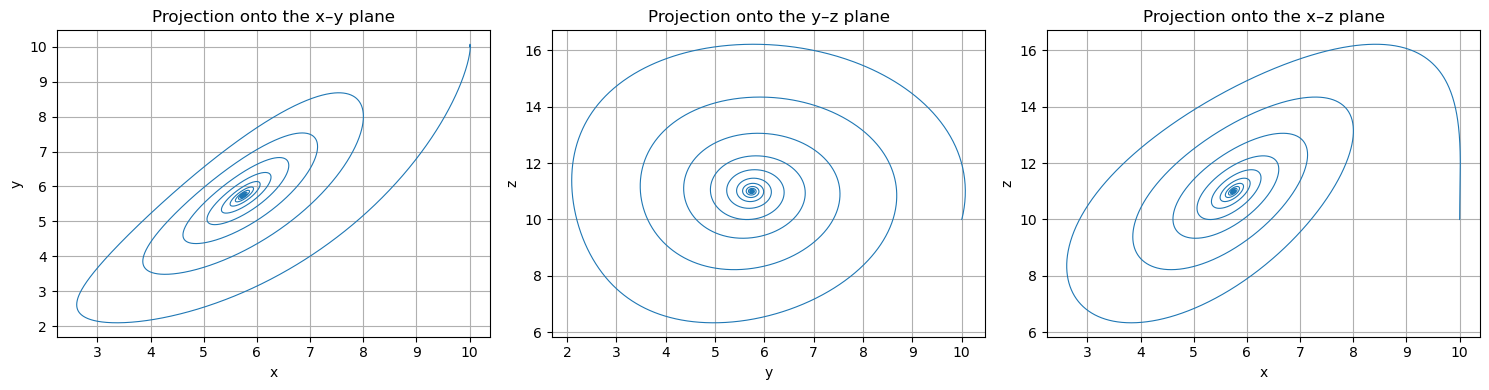

In [35]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters for the Lorenz system
rho = 12.0
sigma = 10.0
beta = 3.0

# Lorenz ODE system
def lorenz(u, t):
    x, y, z = u
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

# Initial condition and time grid
u0 = [10, 10, 10]
t = np.linspace(0, 20, 20000)   # fine time step for smoother curves

# Solve the system
sol = odeint(lorenz, u0, t)
x, y, z = sol.T   # unpack solution

# Plot the three 2-D projections of the trajectory
plt.figure(figsize=(15, 4))

# x–y view
plt.subplot(1, 3, 1)
plt.plot(x, y, lw=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Projection onto the x–y plane")
plt.grid(True)

# y–z view
plt.subplot(1, 3, 2)
plt.plot(y, z, lw=0.8)
plt.xlabel("y")
plt.ylabel("z")
plt.title("Projection onto the y–z plane")
plt.grid(True)

# x–z view
plt.subplot(1, 3, 3)
plt.plot(x, z, lw=0.8)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Projection onto the x–z plane")
plt.grid(True)

plt.tight_layout()
plt.show()


For these parameter values, the Lorenz system has two stable equilibrium points at
$(\sqrt{33}, \sqrt{33}, 11)$ and $(-\sqrt{33},-\sqrt{33}, 11)$.
Since the initial condition starts in the region where both $x$ and $y$ are positive, the trajectory is drawn toward the positive equilibrium.
So as $t \to \infty$, the solution settles at
$(\sqrt{33}, \sqrt{33}, 11)$.

🚩 **Task 2.3 (4 marks)** Consider two different numerical methods: forward Euler and Ruge-kutta (4th order) methods. Set the initial condition to $x = y = z = 100$ and the final time to 0.3. The Ruge-kutta method with timestep h=10^{-6} is accurate enough that **we can regard it as an exact solution**. Using this *estimate numerically* the **global error** for variable $x$ and plot it in log-scale as a function of timestep. In so doing, consider the values `[0.002, 0.001, .0005, 0.0002, 0.0001]` for timesteps. 

Note that the order of error can be estimated from the slope of plots in log-scales. If a function is proportional to $h^{6}$, then in log-scale it looks linear and have the slope of $6$.

What is the slope of global error vs timestep for each method? Why do you get these slopes? You can estimate the slopes by drawing linear guidelines. For example, if you draw $h^{6}$ and your curve is close to this guideline, then you can conclude that the slope is close to $6$. You need to shift your guidelines up and down to bring them closer to the results of numerical solutions. Are the results different than the slopes you expect for the local error as a function of timestep? Can you reason why?


(Remember that you have already implemented forward Euler and Ruge-kutta in your lab notebooks. There is also something called "copy-paste".)

Estimated slope for Euler : 1.1781391650305966
Estimated slope for RK4  : 3.995712482854027


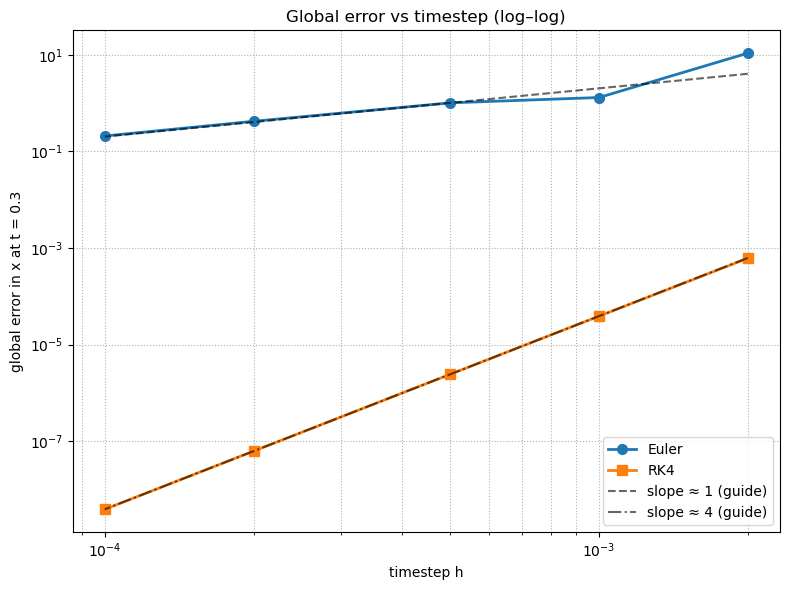

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Euler scheme (from lab/workshop)
def ode_Euler(func, times, y0):
    """
    Integrates the system of y' = func(y, t) using forward Euler method
    for the times in times and given initial condition y0
    """
    times = np.array(times)        # convert times to numpy array
    y0 = np.array(y0)              # convert initial condition to array
    n = y0.size                    # dimension of ODE
    nT = times.size                # number of time steps
    y = np.zeros((nT, n))          # Array to store solution at each time
    y[0, :] = y0                   # Store initial condition

    # loop over timesteps
    for k in range(nT - 1):
        y[k+1, :] = y[k, :] + (times[k+1] - times[k]) * func(y[k, :], times[k])
    return y


# Runge-Kutta 4 scheme (from lab/workshop)
def ode_RK4(func, times, y0):
    times = np.array(times)
    y0 = np.array(y0)
    n = y0.size                  # dimension of ODE
    nT = times.size              # number of time steps
    y = np.zeros((nT, n))
    y[0, :] = y0

    # Loop through time steps
    for k in range(nT - 1):
        dt = times[k+1] - times[k]   # Timestep size
        t = times[k]                 # Current time

        # Four RK4 stages:
        k1 = func(y[k, :], t)
        k2 = func(y[k, :] + 0.5*dt*k1, t + 0.5*dt)
        k3 = func(y[k, :] + 0.5*dt*k2, t + 0.5*dt)
        k4 = func(y[k, :] + dt*k3,   t + dt)

        # RK4 update formula
        y[k+1, :] = y[k, :] + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return y


# Parameters for the Lorenz system
sigma = 10.0
rho   = 28.0
beta  = 8.0 / 3.0

# Lorenz equations
def Lorenz(state, t):
    x, y, z = state
    dxdt = -sigma*x + sigma*y
    dydt = x*(rho - z) - y
    dzdt = x*y - beta*z
    return np.array([dxdt, dydt, dzdt])

# Starting point (all coordinates = 100)
y0 = np.array([100.0, 100.0, 100.0])

# We only integrate up to t = 0.3 for the error test
T_final = 0.3

# A very tiny RK4 step that we treat as “the truth”
h_exact = 1e-6
t_exact = np.arange(0.0, T_final + h_exact, h_exact)
sol_exact = ode_RK4(Lorenz, t_exact, y0)

# We'll compare everything to x(T)
x_exact = sol_exact[-1, 0]

# The stepsizes we actually want to test
hs = np.array([0.002, 0.001, 0.0005, 0.0002, 0.0001])

# Little helper to get x(T) for any method/stepsize combination
def final_x(method, h):
    t = np.arange(0.0, T_final + h, h)
    out = method(Lorenz, t, y0)
    return out[-1, 0]

# Work out how far the numerical answers are from the “truth”
errors_euler = np.abs([final_x(ode_Euler, h) - x_exact for h in hs])
errors_rk4   = np.abs([final_x(ode_RK4,   h) - x_exact for h in hs])

# Fit straight lines in log–log space to estimate slopes
logh = np.log(hs)
slope_euler = np.polyfit(logh, np.log(errors_euler), 1)[0]
slope_rk4   = np.polyfit(logh, np.log(errors_rk4), 1)[0]

print("Estimated slope for Euler :", slope_euler)
print("Estimated slope for RK4  :", slope_rk4)

# Make a log–log plot of the errors
plt.figure(figsize=(8, 6))
plt.loglog(hs, errors_euler, 'o-', lw=2, ms=7, label="Euler")
plt.loglog(hs, errors_rk4,   's-', lw=2, ms=7, label="RK4")

# Use the middle point to anchor reference slopes
mid = len(hs) // 2
h_mid = hs[mid]

# Guideline with slope 1 (Euler-like behaviour)
ref_euler = errors_euler[mid] * (hs / h_mid)**1
plt.loglog(hs, ref_euler, 'k--', alpha=0.6, label="slope ≈ 1 (guide)")

# Guideline with slope 4 (RK4-like behaviour)
ref_rk4 = errors_rk4[mid] * (hs / h_mid)**4
plt.loglog(hs, ref_rk4, 'k-.', alpha=0.6, label="slope ≈ 4 (guide)")

plt.xlabel("timestep h")
plt.ylabel("global error in x at t = 0.3")
plt.title("Global error vs timestep (log–log)")
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()


From the log–log plots, the forward Euler method displays a slope very close to $1$, while the Runge–Kutta method shows a slope close to $4$. This indicates that the global error behaves like $O(h)$ for Euler and $O(h^{4})$ for RK4. These slopes match the theoretical global convergence orders of the two schemes: Euler is a first–order method, and classical RK4 is fourth–order.
The reason these slopes appear is that the global error is the accumulated effect of the local truncation error over approximately $1/h$ steps. For Euler, the local error is $O(h^{2})$, and accumulating this across $1/h$ steps yields a global error of size $O(h)$. Similarly, RK4 has local error $O(h^{5})$, and repeated over $1/h$ steps gives a global error of order $O(h^{4})$. Thus, the slopes observed in the numerical experiment agree with the theoretical prediction that the global convergence order is one power lower than the local truncation error order.

--------------------
### Case of chaotic behaviour and strange attractor


Consider the set of parameters $\sigma = 10$, $\beta = 8/3$ and $\rho = 28$ and stick to Runge-Kutta scheme with timestep of $h = 10^{-4}$ for this part. 

**Task 2.4 (2 marks)** Draw the three-dimensional phase portraits using $x = y = z = 1$ as initial condition. You can use the script below to plot 3D curves.


**Task 2.5 (3 marks)** Change the initial condition as $x = 1 + \epsilon, y = 1, z = 1$, where $\epsilon$ is $10^{-1}$, $10^{-5}$ and $10^{-12}$. Draw the phase portrait for each initial condition and compare it to what you got for Task 2.4. Do they look different? Representing the outputs of these new solutions (with new initial conditions) with $x_1$, $y_1$ and $z_1$ and the solution starting from $x = y = z = 1$ with $x^*$, $y^*$ and $z^*$, compute a measure of difference between these solutions given by
  
\begin{equation*}
\mathcal{e}(t) = \sqrt{(x^*(t) - x_1(t))^2 +  (y^*(t) - y_1(t))^2 + (z^*(t) - z_1(t))^2}.
\end{equation*}
  
Plot the time-series diagrams of $\mathcal{e}(t)$ for three different values of $\epsilon$. From the behaviour of $\mathcal{e}(t)$ answer the following questions:

- If two initial conditions are very close, do their corresponding trajectories stay close to each other in time? 

- Do you see an upper bound for $\mathcal{e}(t)$? What does this imply?
  
  
*The moral of the story is that the exact realisations (the "weather") can have sensitive dependence on initial conditions, and in reality errors always exist, so loss of accuracy in weather prediction is fairly rapid. However there are gross features that remain roughly invariant and can be described, for example the butterfly attractor that you see in your results (the "climate").*

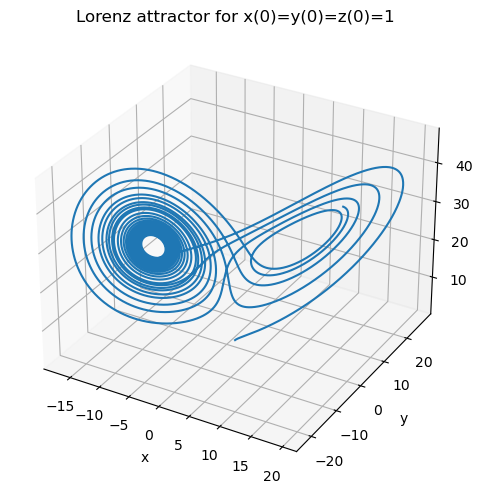

In [37]:
# Task 2.4

# time grid for RK4 integration
T_final = 20.0          # can be increased to see more of the attractor
h = 1e-4
t = np.arange(0.0, T_final + h, h)

# initial condition x = y = z = 1
y0 = np.array([1.0, 1.0, 1.0])

# solve Lorenz system with RK4
sol = ode_RK4(Lorenz, t, y0)
x, y, z = sol.T

# 3D phase portrait
from mpl_toolkits.mplot3d import Axes3D  # needed to enable 3D projection

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")

# plot every 10th point to keep the curve light
ax.plot(x[::10], y[::10], z[::10])

ax.set_title("Lorenz attractor for x(0)=y(0)=z(0)=1")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.tight_layout()
plt.show()


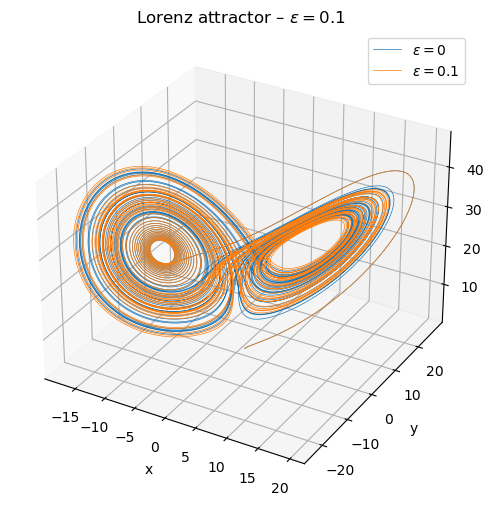

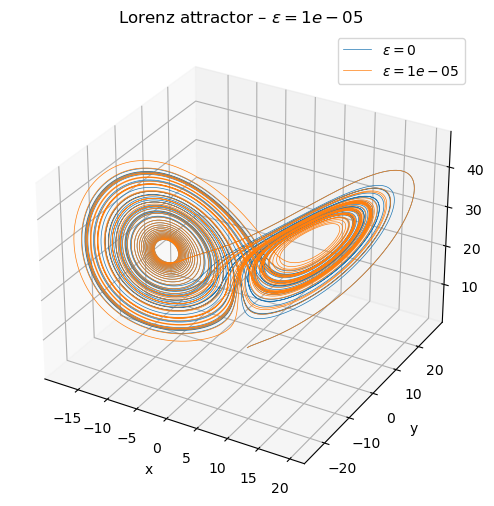

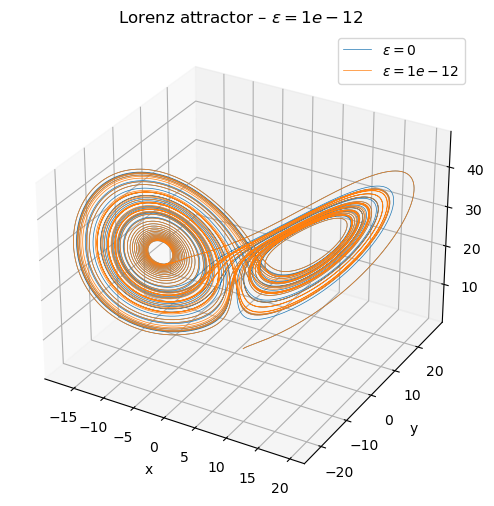

In [38]:
# Task 2.5

# --- recompute the reference trajectory from x=y=z=1 ---
T_final = 50.0
h = 1e-4
t = np.arange(0.0, T_final + h, h)

y0_ref = np.array([1.0, 1.0, 1.0])
sol_ref = ode_RK4(Lorenz, t, y0_ref)
x_ref, y_ref, z_ref = sol_ref.T

# epsilons to try
eps_values = [1e-1, 1e-5, 1e-12]

# to store (eps, e(t))
e_t_list = []

for eps in eps_values:

    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")

    # reference trajectory
    ax.plot(x_ref, y_ref, z_ref, lw=0.5, label=r"$\epsilon = 0$")

    # perturbed initial condition
    y0_pert = [1.0 + eps, 1.0, 1.0]

    # integrate perturbed system
    sol_pert = ode_RK4(Lorenz, t, y0_pert)
    x1, y1, z1 = sol_pert.T

    # plot perturbed trajectory
    ax.plot(x1, y1, z1, lw=0.5, label=fr"$\epsilon = {eps:g}$")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(fr"Lorenz attractor – $\epsilon = {eps:g}$")
    ax.legend()
    plt.show()

    # compute e(t)
    e_t = np.sqrt((x_ref - x1)**2 + (y_ref - y1)**2 + (z_ref - z1)**2)
    e_t_list.append((eps, e_t))


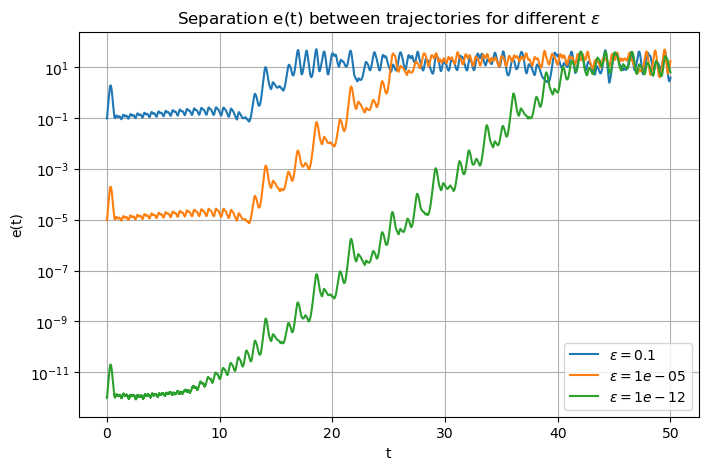

In [39]:
# time-series plots of e(t) for each epsilon
plt.figure(figsize=(8, 5))
for eps, e_t in e_t_list:
    plt.plot(t[:len(e_t)], e_t, label=fr"$\epsilon = {eps:g}$")

plt.xlabel("t")
plt.ylabel("e(t)")
plt.title("Separation e(t) between trajectories for different $\epsilon$")
plt.yscale("log")  # log scale to see growth clearly
plt.grid(True)
plt.legend()
plt.show()


1) For two very close initial conditions, the corresponding trajectories do not stay close in time. Numerically, $e(t)$ starts at a very small value (of order $\epsilon$) but then grows roughly like $\mathrm{e}^{\lambda t}$ for some positive $\lambda$, at least over an initial interval in $t$. This exponential growth of $e(t)$ shows that the Lorenz system has sensitive dependence on initial conditions: even if the difference at $t=0$ is of size $O(\epsilon)$, the separation can become $O(1)$ after a moderate time, so the trajectories diverge and do not remain close.

2) In the plots, $e(t)$ does not grow without bound; after the initial exponential growth it levels off and fluctuates around a value of order $1$–$10$. This means there is an effective upper bound for $e(t)$, which reflects the fact that the Lorenz attractor is bounded in phase space. Both trajectories remain confined to the same compact region, so their distance cannot exceed the diameter of this set. Analytically, this implies the system is chaotic but dissipative: solutions are attracted to a bounded invariant set, and while nearby trajectories separate, they cannot escape to infinity.